          Unemployment Analysis with Python 

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Setup visualization style and suppress warnings
sns.set_theme(style="whitegrid")
warnings.filterwarnings('ignore')

# Load the exact dataset provided
df = pd.read_csv('Unemployment in India.csv')
print("Dataset loaded successfully!")

Dataset loaded successfully!


In [3]:
# 1. Strip leading/trailing spaces from column names (Crucial for this specific dataset)
df.columns = df.columns.str.strip()

# 2. Drop rows where all values are missing (Fixes the 28 empty rows at the end)
df.dropna(how='all', inplace=True)

print("--- Dataset Shape ---")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}\n")

# 3. Type Conversion: Convert 'Date' to datetime object[cite: 1]
# We must use dayfirst=True because the dates are in DD-MM-YYYY format
df['Date'] = pd.to_datetime(df['Date'].str.strip(), dayfirst=True)

# Extract Month and Year for temporal analysis
df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year

print("--- Cleaned Columns ---")
print(df.columns.tolist())


--- Dataset Shape ---
Rows: 740, Columns: 7

--- Cleaned Columns ---
['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)', 'Estimated Employed', 'Estimated Labour Participation Rate (%)', 'Area', 'Month', 'Year']


 explains the negative correlation between the unemployment rate and employed numbers shown in the heatmap.

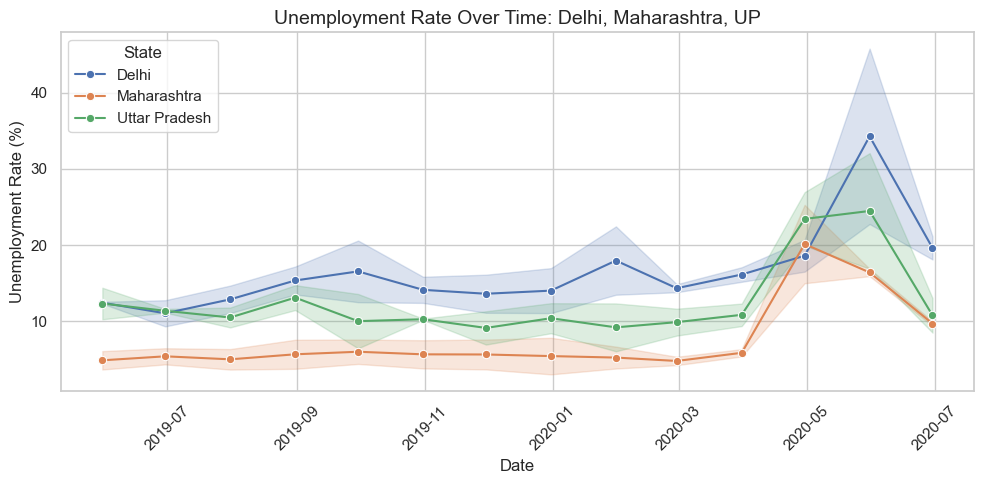

In [4]:
# Select 3 major states for time-series comparison[cite: 1]
states_to_plot = ['Maharashtra', 'Delhi', 'Uttar Pradesh']
filtered_df = df[df['Region'].isin(states_to_plot)]

plt.figure(figsize=(10, 5))
sns.lineplot(data=filtered_df, x='Date', y='Estimated Unemployment Rate (%)', hue='Region', marker='o')

plt.title('Unemployment Rate Over Time: Delhi, Maharashtra, UP', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Unemployment Rate (%)')
plt.xticks(rotation=45)
plt.legend(title='State')
plt.tight_layout()
plt.show()

 explains the initial data cleaning and datetime conversion.


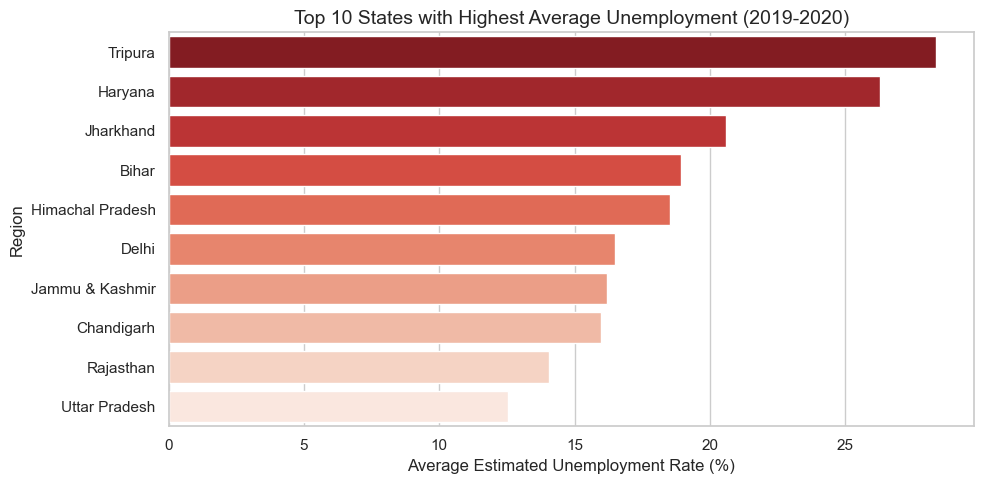

In [5]:
# Calculate region-wise average unemployment rates[cite: 1]
region_stats = df.groupby('Region')['Estimated Unemployment Rate (%)'].mean().reset_index()
region_stats = region_stats.sort_values(by='Estimated Unemployment Rate (%)', ascending=False)

# Plot the top 10 states[cite: 1]
plt.figure(figsize=(10, 5))
sns.barplot(data=region_stats.head(10), x='Estimated Unemployment Rate (%)', y='Region', palette='Reds_r')

plt.title('Top 10 States with Highest Average Unemployment (2019-2020)', fontsize=14)
plt.xlabel('Average Estimated Unemployment Rate (%)')
plt.ylabel('Region')
plt.tight_layout()
plt.show()

explains the massive spike in the time-series line chart (attributing it directly to the April/May lockdowns).

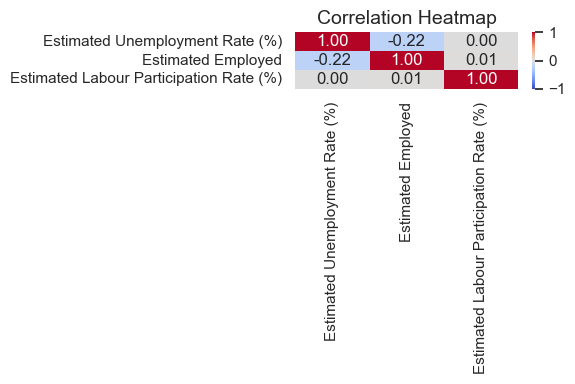

In [7]:
# Select relevant numeric columns for the heatmap[cite: 1]
cols_for_corr = ['Estimated Unemployment Rate (%)', 'Estimated Employed', 'Estimated Labour Participation Rate (%)']
corr_matrix = df[cols_for_corr].corr()

plt.figure(figsize=(6, 4))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)

plt.title('Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.show()

In [8]:
# Define the lockdown cutoff date (March 24, 2020)[cite: 1]
lockdown_start = pd.to_datetime('2020-03-24')

# Split the data[cite: 1]
pre_covid = df[df['Date'] < lockdown_start]
post_covid = df[df['Date'] >= lockdown_start]

# Calculate mean rates for each period[cite: 1]
pre_covid_mean = pre_covid['Estimated Unemployment Rate (%)'].mean()
post_covid_mean = post_covid['Estimated Unemployment Rate (%)'].mean()

print("--- COVID-19 Impact Analysis ---")
print(f"Average Unemployment Rate (Pre-COVID):  {pre_covid_mean:.2f}%")
print(f"Average Unemployment Rate (Post-COVID): {post_covid_mean:.2f}%")
print(f"Absolute Increase:                      {post_covid_mean - pre_covid_mean:.2f}%")

--- COVID-19 Impact Analysis ---
Average Unemployment Rate (Pre-COVID):  9.51%
Average Unemployment Rate (Post-COVID): 17.77%
Absolute Increase:                      8.26%
